In [2]:
# Chunk 1: Setup, Feature Engineering, and Data Preparation for XGBoost

# Install necessary packages in Colab, including XGBoost
!pip install optuna shap xgboost -q

import logging
from pathlib import Path
from typing import Tuple, Dict, Any, List
from collections import Counter
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
# --- XGBoost Import ---
from xgboost import XGBClassifier
from IPython.display import display
import xgboost

# --- Mount Google Drive ---
from google.colab import drive
try:
    drive.mount('/content/drive')
except:
    print("Drive already mounted or unavailable. Skipping mount.")

# --------- logging ---------
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)
RND = 42
np.random.seed(RND) # Set global seed for reproducibility

# --- Define the path to your data ---
# --- Define the path to your data on Google Drive ---
DRIVE_DATA_PATH = Path("/content/drive/MyDrive/MachineLearning/data/processed_V2")
FINAL_ENGINEERED_FILE = "clean_numeric_engineered_v2.csv" # New file name

# --- Execute the setup and feature engineering ---
print("\n--- Loading Base Data and Creating Engineered Features ---")
try:
    BASE_FILE_NAME = "clean_numeric_model.csv"
    # User_ID is used as the row_id/index in the splits file, so we read it without setting an index
    base_df = pd.read_csv(DRIVE_DATA_PATH / BASE_FILE_NAME)
    print(f"Successfully loaded '{BASE_FILE_NAME}'.")

    # Store the row_id/index needed for merging splits
    base_df = base_df.reset_index().rename(columns={"index": "row_id"})

    # --- Feature Engineering ---
    base_df['Work_Sleep_Ratio'] = base_df['Work_Hours'] / (base_df['Sleep_Hours'] + 0.01)
    base_df['Stress_x_Smoking'] = base_df['Stress_Level_ord'] * base_df['Smoking_Habit_ord']
    base_df['Stress_x_Alcohol'] = base_df['Stress_Level_ord'] * base_df['Alcohol_Consumption_ord']
    base_df['High_Risk_Pattern_Flag'] = ( (base_df['Stress_Level_ord'] >= 2) & (base_df['Sleep_Hours'] < 6) & (base_df['Physical_Activity_Hours'] < 2)).astype(int)
    base_df['Sleep_Deviation'] = abs(base_df['Sleep_Hours'] - 7.5)
    base_df['Digital_Overload_Score'] = base_df['Work_Hours'] + base_df['Social_Media_Usage']
    base_df['Age_Squared'] = base_df['Age']**2
    base_df['Age_x_SM_Usage'] = base_df['Age'] * base_df['Social_Media_Usage']
    base_df['Age_x_Work_Hours'] = base_df['Age'] * base_df['Work_Hours']
    base_df['Health_Habit_Deficit'] = (
        (base_df['Sleep_Deviation'] / 3.0) +
        (3 - base_df['Diet_Quality_ord']) +
        (10 - base_df['Physical_Activity_Hours']) / 10
    )

    # --- CRITICAL SAVE STEP ---
    base_df.to_csv(DRIVE_DATA_PATH / FINAL_ENGINEERED_FILE, index=False)
    print(f"\n✅ Engineered data successfully saved as '{FINAL_ENGINEERED_FILE}'.")
    # ---------------------------

    # Define target
    TARGET = 'Has_MH_condition_bin'
    # Check current status
    y = base_df[TARGET]

    print(f"\nTotal Features (including target and index) Ready: {len(base_df.columns)}")
    print(f"Target Class Balance: {Counter(y)}")
    print(f"First 5 columns of the saved data: {base_df.columns[:5].tolist()}")


except FileNotFoundError:
    print(f"ERROR: Could not find the base '{BASE_FILE_NAME}' file.")
except KeyError as e:
    print(f"ERROR: Column {e} not found. Please check your feature/target names.")


print("\n✅ Chunk 1 Complete: Setup and feature engineering finished.")

Mounted at /content/drive

--- Loading Base Data and Creating Engineered Features ---
Successfully loaded 'clean_numeric_model.csv'.

✅ Engineered data successfully saved as 'clean_numeric_engineered_v2.csv'.

Total Features (including target and index) Ready: 35
Target Class Balance: Counter({0: 25003, 1: 24997})
First 5 columns of the saved data: ['row_id', 'User_ID', 'Age', 'Sleep_Hours', 'Work_Hours']

✅ Chunk 1 Complete: Setup and feature engineering finished.


In [12]:
# Chunk 2: Define All Core Functions for XGBoost (Final, Revised Version)

# --- Standard Imports ---
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import shap
import matplotlib.pyplot as plt
import logging
from pathlib import Path
from typing import Tuple, Dict, Any, List

# --- Scikit-learn Imports ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report,brier_score_loss
from xgboost import XGBClassifier
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# --- Configuration ---
# It's good practice to define constants at the top
RND = 42
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

# ==============================================================================
# 1. DATA LOADING FUNCTION
# ==============================================================================
def load_and_split_data(base_dir: Path) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    REVISED: Switched to the binary target, ensures all identifiers including 'row_id'
    are dropped from the feature sets (X) at the source.
    """
    data_path = base_dir / "clean_numeric_engineered_v2.csv"
    splits_path = base_dir / "splits_70_15_15_k5.csv"

    if not data_path.exists() or not splits_path.exists():
        raise FileNotFoundError(f"Data files not found in {base_dir}.")

    df = pd.read_csv(data_path)
    if "row_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "row_id"})

    splits = pd.read_csv(splits_path)
    df = df.merge(splits, on="row_id", how="left")

    train_df, val_df, test_df = df[df["split"] == "train"].copy(), df[df["split"] == "val"].copy(), df[df["split"] == "test"].copy()

    TARGET_COL = "Has_MH_condition_bin"

    # REVISION: Added "row_id" to the drop list to avoid filtering it in every function.
    drop_list = ["User_ID", "Severity_ord", "Mental_Health_Condition_lbl", "split", "cv_fold", "row_id", TARGET_COL]
    drop_cols = [c for c in drop_list if c in train_df.columns]

    X_train, y_train = train_df.drop(columns=drop_cols), train_df[TARGET_COL].astype(int)
    X_val, y_val = val_df.drop(columns=drop_cols), val_df[TARGET_COL].astype(int)
    X_test, y_test = test_df.drop(columns=drop_cols), test_df[TARGET_COL].astype(int)

    logger.info(f"Loaded splits: train={len(y_train)}, val={len(y_val)}, test={len(y_test)}")
    return X_train, y_train, X_val, y_val, X_test, y_test

# ==============================================================================
# 2. HYPERPARAMETER TUNING FUNCTION
# ==============================================================================
def tune_xgb_optuna(
    X_train: pd.DataFrame, y_train: pd.Series,
    n_trials: int = 30, cv_folds: int = 5,
) -> Tuple[Any, Dict[str, Any]]:
    """
    REVISED: Removed the confusing 'sample_weight' parameter to rely solely on
    'scale_pos_weight' for handling class imbalance, which is being tuned.
    Finds the optimal F1 threshold in each CV fold for more robust tuning.
    """
    X, y = X_train.copy().reset_index(drop=True), y_train.copy().reset_index(drop=True)

    def obj(trial: "optuna.trial.Trial") -> float:
        params = {
            "max_depth": trial.suggest_int("max_depth", 4, 12),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10, log=True),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.1, 5.0, log=True),
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "n_estimators": 5000,
            "random_state": RND,
            "tree_method": "hist",
            "n_jobs": -1
        }

        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RND)
        f1s, best_iters_fold = [], []

        for tr_idx, va_idx in skf.split(X, y):
            X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
            y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

            clf = XGBClassifier(early_stopping_rounds=100, **params)

            # REVISION: Removed sample_weight from the fit method
            clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            y_pred_proba = clf.predict_proba(X_va)[:, 1]

            best_f1 = 0.0
            for t in np.linspace(0.01, 0.99, 50):
                f1 = f1_score(y_va, (y_pred_proba >= t).astype(int), average="binary")
                if f1 > best_f1:
                    best_f1 = f1
            f1s.append(best_f1)

            best_iters_fold.append(clf.best_iteration)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("avg_best_iter", np.mean(best_iters_fold))
        return float(np.mean(f1s))

    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RND), pruner=MedianPruner())
    study.optimize(obj, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params
    avg_iter = study.best_trial.user_attrs.get("avg_best_iter", 500)
    best_params["n_estimators"] = int(np.clip(int(1.1 * avg_iter), 100, 5000))

    return study, best_params

# ==============================================================================
# 3. FINAL MODEL TRAINING FUNCTION
# ==============================================================================
def train_final_xgb(
    X_train: pd.DataFrame, y_train: pd.Series, X_val: pd.DataFrame, y_val: pd.Series,
    params: Dict[str, Any],
) -> XGBClassifier:
    """
    REVISED: Removed the 'sample_weight' parameter for clarity. Trains the final
    binary XGBoost model using the best hyperparameters.
    """
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RND,
        n_jobs=-1,
        early_stopping_rounds=50,
        **params
    )

    # REVISION: No sample_weight, no feature filtering needed
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    logger.info("Trained final XGBoost. Best iter: %s", model.best_iteration)
    return model

# ==============================================================================
# 4. EVALUATION FUNCTIONS
# ==============================================================================
def find_optimal_threshold(model: XGBClassifier, X_val: pd.DataFrame, y_val: pd.Series) -> float:
    """
    NEW: Finds the optimal F1 threshold on the validation set to ensure the test
    evaluation is consistent with the tuning objective.
    """
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    best_f1 = 0.0
    best_threshold = 0.5

    for threshold in np.linspace(0.01, 0.99, 100):
        preds = (y_pred_proba >= threshold).astype(int)
        f1 = f1_score(y_val, preds, average="binary")
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"\nFound optimal F1 threshold on validation set: {best_threshold:.4f} (Validation F1 = {best_f1:.4f})")
    return best_threshold

from sklearn.metrics import f1_score, roc_auc_score, classification_report, brier_score_loss # Make sure brier_score_loss is imported!

def evaluate(model: XGBClassifier, X_test: pd.DataFrame, y_test: pd.Series, out_dir: Path, threshold: float = 0.5):
    """
    REVISED: Now accepts and uses an optimal threshold for making predictions on the test set.
    Calculates Macro F1, Macro AUC, and Brier Score.
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)

    # --- METRIC CALCULATIONS (UPDATED) ---
    f1_macro = f1_score(y_test, preds, average="macro")
    auc_macro = roc_auc_score(y_test, probs, average="macro") # For binary cases, 'macro' is often default but good to be explicit
    brier = brier_score_loss(y_test, probs)

    # --- PRINTING RESULTS (UPDATED) ---
    print(f"\nTest Set Metrics (using threshold={threshold:.4f}):")
    print(f"  - Macro F1-Score: {f1_macro:.4f}")
    print(f"  - Macro ROC AUC Score: {auc_macro:.4f}")
    print(f"  - Brier Score: {brier:.4f}")

    report = classification_report(y_test, preds, target_names=["absent (0)", "present (1)"])
    with open(out_dir / "classification_report.txt", "w") as fh:
        fh.write(report)

    print("\n--- Final Model Classification Report (Binary) ---")
    print("This report shows the performance of the fully-tuned model on the unseen test data.")
    print(report)
    pred_counts = pd.Series(preds).value_counts().sort_index().to_dict()
    print(f"Prediction counts on test set: {pred_counts}")

# ==============================================================================
# 5. SHAP INTERPRETABILITY FUNCTION
# ==============================================================================
def compute_and_save_shap(model: XGBClassifier, X: pd.DataFrame, out_dir: Path):
    """Handles the 2D SHAP output for binary classification (log-odds)."""
    print("\n--- Generating SHAP values using the modern shap.Explainer API ---")
    explainer = shap.Explainer(model)
    shap_explanation = explainer(X)
    out_dir.mkdir(parents=True, exist_ok=True)
    print("--- Generating and saving SHAP plots ---")

    plot_path = out_dir / "shap_summary_binary.png"
    plt.figure()
    shap.summary_plot(shap_explanation, X, show=False)
    plt.title("SHAP Summary (Log-Odds for Presence)")
    plt.tight_layout()
    plt.savefig(plot_path)
    plt.close()

    print(f"SHAP summary plot saved to: {plot_path}")
    print("\nDisplaying SHAP plot:")
    try:
        from IPython.display import Image, display
        display(Image(filename=plot_path))
    except Exception as e:
        print(f"Could not display image. Ensure you are in a Jupyter environment. Error: {e}")

print("\n✅ Chunk 2 Complete: All revised core functions for XGBoost are now defined.")


✅ Chunk 2 Complete: All revised core functions for XGBoost are now defined.


In [13]:
# Chunk 3: Run Hyperparameter Tuning for XGBoost (Revised)

import json # Best practice: move imports to the top of the script
from pathlib import Path

# --- Assume DRIVE_DATA_PATH is defined, e.g. ---
# DRIVE_DATA_PATH = Path("./data")

# --- Step 1: Loading data for tuning ---
print("--- Step 1: Loading data for tuning ---")
X_train, y_train, X_val, y_val, X_test, y_test = load_and_split_data(DRIVE_DATA_PATH)
print("Data loaded.")
print(f"Training data shape: {X_train.shape}")
print(f"Training label distribution:\n{y_train.value_counts(normalize=True).round(2)}")

# --- Step 2: (REMOVED) The get_sample_weights step is no longer needed. ---
# The 'scale_pos_weight' hyperparameter in the tuning function now handles class imbalance.

# --- Step 3: Starting hyperparameter tuning with Optuna for XGBoost ---
print("\n--- Step 2: Starting hyperparameter tuning with Optuna for XGBoost ---")
print("This will take some time...")

# The call is correct for the CV-based tuning function from Chunk 2.
study, best_params = tune_xgb_optuna(X_train, y_train, n_trials=30) # Example with 30 trials

# --- Tuning Complete ---
print("\n--- Tuning Complete ---")
# REVISION: Clarified the metric name for accuracy.
print(f"Best F1-score found during search (avg. over CV folds): {study.best_value:.4f}")
print("Best parameters to be used for the final XGBoost model:")
print(json.dumps(best_params, indent=2))

print("\n✅ Chunk 3 Complete: XGBoost hyperparameter tuning finished.")

[I 2025-10-10 22:23:43,075] A new study created in memory with name: no-name-37307095-cff6-4c01-a09b-39a3fc19b848


--- Step 1: Loading data for tuning ---
Data loaded.
Training data shape: (34999, 30)
Training label distribution:
Has_MH_condition_bin
0    0.5
1    0.5
Name: proportion, dtype: float64

--- Step 2: Starting hyperparameter tuning with Optuna for XGBoost ---
This will take some time...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-10-10 22:23:47,174] Trial 0 finished with value: 0.6666031673460171 and parameters: {'max_depth': 7, 'learning_rate': 0.1667521176194013, 'subsample': 0.9195981825434215, 'colsample_bytree': 0.8795975452591109, 'gamma': 0.7800932022121826, 'reg_alpha': 8.629132190071849e-05, 'reg_lambda': 2.231010801867923e-05, 'scale_pos_weight': 2.962151658830348}. Best is trial 0 with value: 0.6666031673460171.
[I 2025-10-10 22:23:49,585] Trial 1 finished with value: 0.6666031673460171 and parameters: {'max_depth': 9, 'learning_rate': 0.06813099824138592, 'subsample': 0.7061753482887407, 'colsample_bytree': 0.9909729556485982, 'gamma': 4.162213204002109, 'reg_alpha': 0.00018794668241638458, 'reg_lambda': 0.00012329623163659834, 'scale_pos_weight': 0.20492680115417347}. Best is trial 0 with value: 0.6666031673460171.
[I 2025-10-10 22:23:53,665] Trial 2 finished with value: 0.6666031673460171 and parameters: {'max_depth': 6, 'learning_rate': 0.034646653174710614, 'subsample': 0.829583505592634

--- Step 1: Training final XGBoost model with best parameters ---
Final XGBoost model training complete.

--- Step 2: Saving the trained XGBoost model ---
Final XGBoost model successfully saved to: /content/drive/MyDrive/MachineLearning/outputs_xgboost_binary_v1/xgb_final_model.joblib

--- Step 3: Finding the optimal classification threshold ---

Found optimal F1 threshold on validation set: 0.4654 (Validation F1 = 0.6667)

--- Step 4: Evaluating the final XGBoost model on the test set ---

Test Set Metrics (using threshold=0.4654):
  - Macro F1-Score: 0.3374
  - Macro ROC AUC Score: 0.5113
  - Brier Score: 0.2870

--- Final Model Classification Report (Binary) ---
This report shows the performance of the fully-tuned model on the unseen test data.
              precision    recall  f1-score   support

  absent (0)       0.52      0.00      0.01      3751
 present (1)       0.50      1.00      0.67      3751

    accuracy                           0.50      7502
   macro avg       0.51 

/tmp/ipython-input-3916232434.py:227: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_explanation, X, show=False)


SHAP summary plot saved to: /content/drive/MyDrive/MachineLearning/outputs_xgboost_binary_v1/shap_summary_binary.png

Displaying SHAP plot:


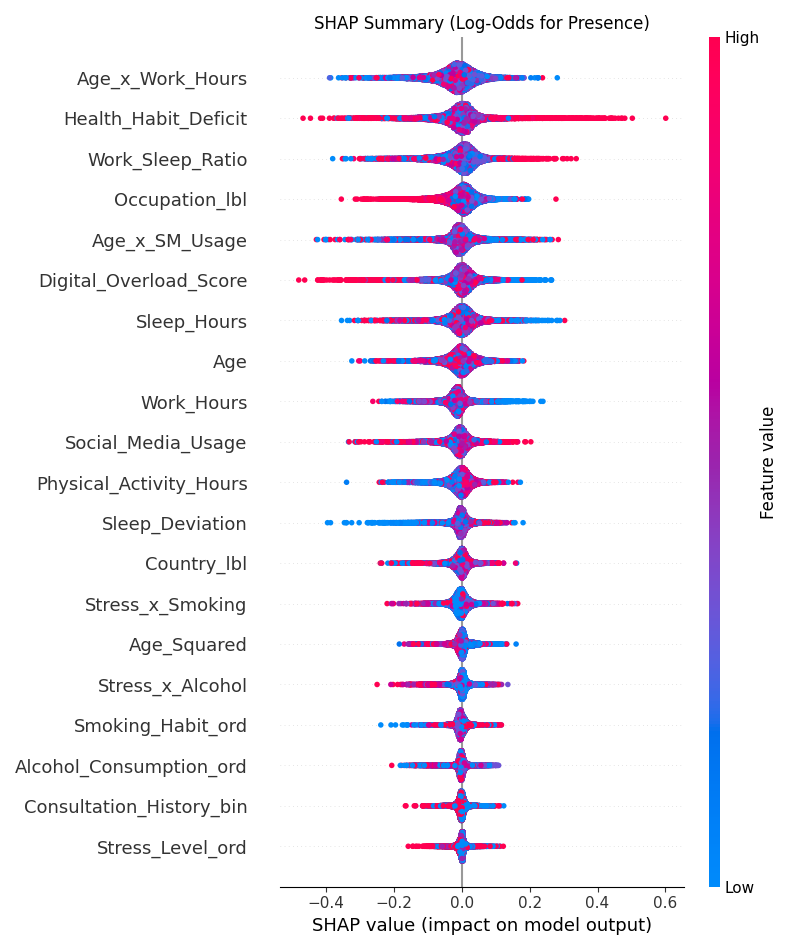


✅ Chunk 4 Complete: Final XGBoost model trained, saved, and evaluated.


In [14]:
# Chunk 4: Train and Evaluate the Final XGBoost Model (Revised)

import joblib
from pathlib import Path

# --- Assume previous chunks have been run and the following are defined: ---
# X_train, y_train, X_val, y_val, X_test, y_test
# best_params (from Optuna tuning)

# --- Step 1: Training final XGBoost model with best parameters ---
print("--- Step 1: Training final XGBoost model with best parameters ---")
final_model = train_final_xgb(X_train, y_train, X_val, y_val, best_params)
print("Final XGBoost model training complete.")

# --- Step 2: Saving the trained XGBoost model ---
print("\n--- Step 2: Saving the trained XGBoost model ---")
# Define a clear, versioned output directory
out_dir = Path("/content/drive/MyDrive/MachineLearning/outputs_xgboost_binary_v1")
out_dir.mkdir(parents=True, exist_ok=True)
model_path = out_dir / "xgb_final_model.joblib" # Using .joblib extension is good practice
joblib.dump(final_model, model_path)
print(f"Final XGBoost model successfully saved to: {model_path}")


# --- Step 3: Find the optimal threshold on the validation set ---
print("\n--- Step 3: Finding the optimal classification threshold ---")
# This is the critical step to connect tuning with evaluation.
optimal_thresh = find_optimal_threshold(final_model, X_val, y_val)


# --- Step 4: Evaluating the final model on the test set ---
print("\n--- Step 4: Evaluating the final XGBoost model on the test set ---")
# Pass the optimal threshold to the evaluate function.
evaluate(final_model, X_test, y_test, out_dir, threshold=optimal_thresh)


# --- (Optional) Step 5: Generate and save SHAP interpretability plots ---
print("\n--- Step 5: Generating SHAP values for model interpretability ---")
# Use the training data for a representative explanation of the model's behavior.
compute_and_save_shap(final_model, X_train, out_dir)


print("\n✅ Chunk 4 Complete: Final XGBoost model trained, saved, and evaluated.")

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import StandardScaler
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data ONLY and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Don't forget to scale the test data too

# Train a simple baseline ON THE SCALED DATA
log_reg = LogisticRegression(random_state=RND, max_iter=1000)
log_reg.fit(X_train_scaled, y_train) # <-- Use X_train_scaled here

# Evaluate ON THE SCALED DATA
probs = log_reg.predict_proba(X_test_scaled)[:, 1] # <-- Use X_test_scaled here
auc = roc_auc_score(y_test, probs)
print(f"Logistic Regression Baseline ROC AUC: {auc:.4f}")

Logistic Regression Baseline ROC AUC: 0.4894
